# Day 11 — A Proper Capillary Tube Model (Length *and* Bore Diameter)
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** Day 8's model only considered tube **length**, using a straight-line calibration that (as that notebook showed) breaks down outside a narrow range. Real capillary tube selection charts — the ones actually used on the factory floor — depend on **both length and internal diameter (bore)**, and follow real fluid-mechanics: friction factor, Reynolds number, the works (the **Darcy-Weisbach equation**).

This notebook builds that proper model and produces a **selection map**: for four common bore sizes (0.5mm–0.8mm), it shows what length is needed to hit a target evaporator temperature of **-25°C**, and what COP results.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Darcy-Weisbach pressure drop model + cycle function
def cap_tube_pressure_drop(L, D, T_cond_C, refrigerant="R600a", m_dot=0.001):
    T_cond_K   = T_cond_C + 273.15
    P_cond     = CP.PropsSI("P","T",T_cond_K,"Q",0,refrigerant)
    rho_liquid = CP.PropsSI("D","T",T_cond_K,"Q",0,refrigerant)
    mu_liquid  = CP.PropsSI("V","T",T_cond_K,"Q",0,refrigerant)
    A_cross    = np.pi*(D/2)**2
    velocity   = m_dot/(rho_liquid*A_cross)
    Re         = rho_liquid*velocity*D/mu_liquid
    f          = 64/Re if Re < 2300 else 0.316/(Re**0.25)   # laminar vs turbulent friction factor
    delta_P    = f*(L/D)*(rho_liquid*velocity**2/2)
    P_evap_new = P_cond - delta_P
    if P_evap_new <= 0: return None, None
    T_evap_new = CP.PropsSI("T","P",P_evap_new,"Q",1,refrigerant) - 273.15
    return P_evap_new, T_evap_new

def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    return (h1-h4)/(h2-h1), 100/(h1-h4), h1, h2, h3, h4, P_evap, P_cond

In [4]:
# CELL 4 — Sweep length for 4 bore diameters
T_cond_C  = 40
diameters = {"0.5mm":0.0005,"0.6mm":0.0006,"0.7mm":0.0007,"0.8mm":0.0008}
L_range   = np.linspace(1.5, 4.5, 30)
m_dot_est = 0.001

print(f"{'Bore':<8}{'Length for -25C target':<26}")
for lbl, D in diameters.items():
    best_L, best_diff = None, 999
    for L in L_range:
        _, T = cap_tube_pressure_drop(L, D, T_cond_C, m_dot=m_dot_est)
        if T is not None and abs(T - (-25)) < best_diff:
            best_diff, best_L = abs(T-(-25)), L
    print(f"{lbl:<8}{best_L:.2f} m" if best_L else f"{lbl:<8}out of range")

Bore    Length for -25C target    
0.5mm   out of range
0.6mm   out of range
0.7mm   1.81 m
0.8mm   3.36 m


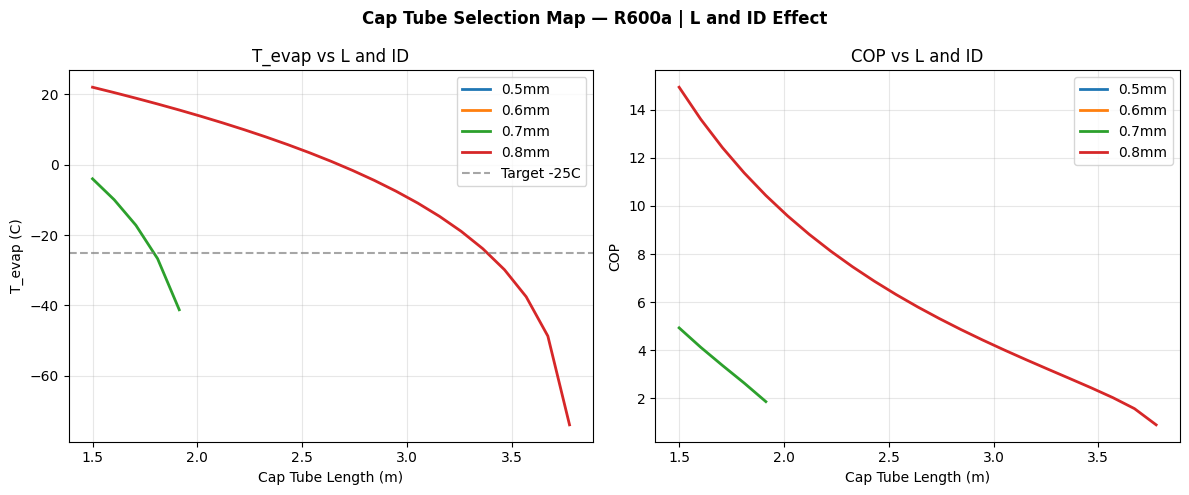

In [5]:
# CELL 5 — Selection map: T_evap and COP vs Length, for each bore
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for lbl,D in diameters.items():
    T_list = []
    for L in L_range:
        _,T = cap_tube_pressure_drop(L,D,T_cond_C,m_dot=m_dot_est)
        T_list.append(T)
    plt.plot(L_range,T_list,linewidth=2,label=lbl)
plt.axhline(y=-25,color="gray",linestyle="--",alpha=0.7,label="Target -25C")
plt.xlabel("Cap Tube Length (m)"); plt.ylabel("T_evap (C)")
plt.title("T_evap vs L and ID"); plt.legend(); plt.grid(True,alpha=0.3)

plt.subplot(1,2,2)
for lbl,D in diameters.items():
    COP_list = []
    for L in L_range:
        _,T = cap_tube_pressure_drop(L,D,T_cond_C,m_dot=m_dot_est)
        if T:
            try:
                COP,*_ = calculate_cycle(T,T_cond_C)
                COP_list.append(COP)
            except: COP_list.append(None)
        else: COP_list.append(None)
    plt.plot(L_range,COP_list,linewidth=2,label=lbl)
plt.xlabel("Cap Tube Length (m)"); plt.ylabel("COP")
plt.title("COP vs L and ID"); plt.legend(); plt.grid(True,alpha=0.3)

plt.suptitle("Cap Tube Selection Map — R600a | L and ID Effect",fontweight="bold")
plt.tight_layout()
plt.savefig("day11_captube_LD_model.png",dpi=150)
plt.show()

**What this graph tells us:** only the **0.7mm and 0.8mm curves actually appear** on the chart — at the fixed flow rate assumed here (1 g/s), the 0.5mm and 0.6mm bores are *too restrictive*: pressure drops below zero (physically invalid) almost immediately, before even the shortest length in the sweep. That's a real and useful finding, not just a missing line — it tells you those two bores simply aren't practical for this duty at this flow rate.

Between the two valid bores, the pattern is exactly what fluid mechanics predicts: the **narrower 0.7mm tube reaches the -25°C target at a much shorter length (~1.8m)** than the **wider 0.8mm tube (~3.3m)** — a narrower bore restricts flow more per metre, so it needs less length to create the same pressure drop. This is the real selection logic factories use: pick a bore your tubing supplier/equipment can make consistently, then read the matching length straight off a chart like this one — instead of redoing the fluid mechanics by hand for every design change. Compared to Day 8's single-point calibration, this Darcy-Weisbach model stays physically honest about *where it breaks down*, rather than silently extrapolating past its valid range.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day11_captube_LD_model.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 11 - Darcy-Weisbach cap tube model (L and ID)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 11 - Darcy-Weisbach cap tube model (L and ID)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
